In [1]:
import scanpy as sc
import pandas as pd
from tqdm import tqdm
from pathlib import Path

In [2]:
adata_file = './outs/adata/small_harmony.h5ad'
copykat_dir = './outs/copykat/'
out_dir = './outs/adata/'

Load Data

In [3]:
adata = sc.read_h5ad(adata_file)
adata.var_names = list(adata.var['gene_names'])
adata.var_names_make_unique()
adata

AnnData object with n_obs × n_vars = 128362 × 22212
    obs: 'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'doublet_score', 'predicted_doublet', 'sample', 'dataset'
    var: 'gene_ids', 'gene_names', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'hvg', 'log1p', 'neighbors', 'pca', 'sample_colors', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

In [4]:
copykats = []
for f in tqdm(Path(copykat_dir).glob('./*/*_copykat_prediction.txt'), total=len(list(Path(copykat_dir).glob('./*/*_copykat_prediction.txt')))):
    id = f.parent.name
    copykat = pd.read_csv(f, sep='\t', header=0, index_col=0)
    copykats.append(copykat)
# concatenate
copykat_pred = pd.concat(copykats, axis=0, join='outer')
copykat_pred = copykat_pred.rename({'copykat.pred': 'copykat_pred'}, axis=1)
copykat_pred

  0%|                                                                                                                                                                                                | 0/23 [00:00<?, ?it/s]

 70%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌                                                       | 16/23 [00:00<00:00, 158.57it/s]

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 23/23 [00:00<00:00, 158.56it/s]

,copykat_pred
cell.names,
AAACATCGAAACATCGACACGACC,diploid
AAACATCGAAACATCGCCTCTATC,diploid
AAACATCGAACAACCACCGAAGTA,diploid
AAACATCGAACAACCACGCATACA,diploid
AAACATCGAACGTGATAATGTTGC,diploid
...,...
TTTGGTTTCGGTCCGA-1,not.defined
TTTGTCACAGCATGAG-1,not.defined
TTTGTCAGTAAATACG-1,not.defined


In [5]:
# add to adata
adata.obs = adata.obs.join(copykat_pred, how='left')
adata.obs

,n_genes,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,doublet_score,predicted_doublet,sample,dataset,copykat_pred
AAACATCGAACAACCAAGCACCTC,861,901,6.804615,1912.0,7.556428,39.539749,50.000000,61.297071,79.027197,213.0,5.365976,11.140167,0.011382,False,ZCLM12,new,diploid
AAACATCGAACCGAGAATTGGCTC,2128,2224,7.707512,5145.0,8.545975,28.551992,36.190476,45.539359,60.971817,474.0,6.163315,9.212828,0.049560,False,ZCLM12,new,aneuploid
AAACATCGAACCGAGACGCATACA,1722,1799,7.495542,4649.0,8.444622,33.103893,42.245644,52.699505,69.219187,518.0,6.251904,11.142180,0.015393,False,ZCLM12,new,diploid
AAACATCGAACGCTTATAGGATGA,2383,2498,7.823646,7764.0,8.957382,36.437403,45.002576,53.812468,67.645544,626.0,6.440947,8.062855,0.015393,False,ZCLM12,new,diploid
AAACATCGAACGCTTATATCAGCA,1392,1466,7.290975,3885.0,8.265136,39.768340,49.806950,59.459459,75.135135,553.0,6.317165,14.234235,0.053711,False,ZCLM12,new,diploid
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTCACGCATGGAACAACCGACAAC,692,720,6.580639,1327.0,7.191429,43.029390,50.565185,60.813866,83.421251,158.0,5.068904,11.906556,0.025641,False,CHY20,new,not.defined
TTCACGCATGGAACAACTAAGGTC,950,1028,6.936343,2019.0,7.610853,29.420505,40.118871,53.046062,73.848440,20.0,3.044523,0.990589,0.036795,False,CHY20,new,aneuploid
TTCACGCATGGCTTCAAACTCACC,1474,1544,7.342779,3297.0,8.101071,32.939035,40.855323,50.925083,68.334850,303.0,5.717028,9.190173,0.015119,False,CHY20,new,diploid
TTCACGCATGGCTTCACCAGTTCA-1,555,581,6.366470,814.0,6.703188,32.063882,40.909091,53.194103,90.049140,118.0,4.779123,14.496315,0.016873,False,CHY20,new,not.defined


/data1/hounaiqiao/.conda/envs/sc/lib/python3.12/site-packages/anndata/_core/anndata.py:1145: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


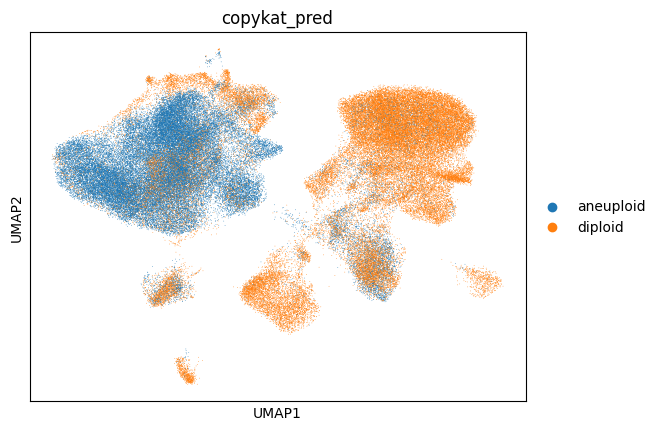

In [6]:
# visualize
sc.pl.umap(adata[adata.obs['copykat_pred'] != 'not.defined'], color=['copykat_pred'])

Broad Cluster

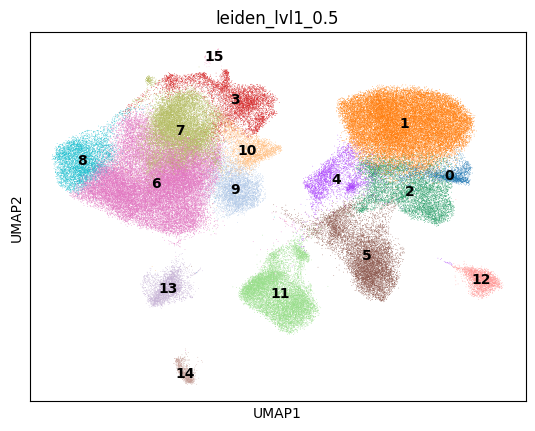

In [7]:
sc.tl.leiden(adata, resolution=0.5, key_added='leiden_lvl1_0.5', flavor='igraph')
sc.pl.umap(adata, color=['leiden_lvl1_0.5'], legend_loc='on data')

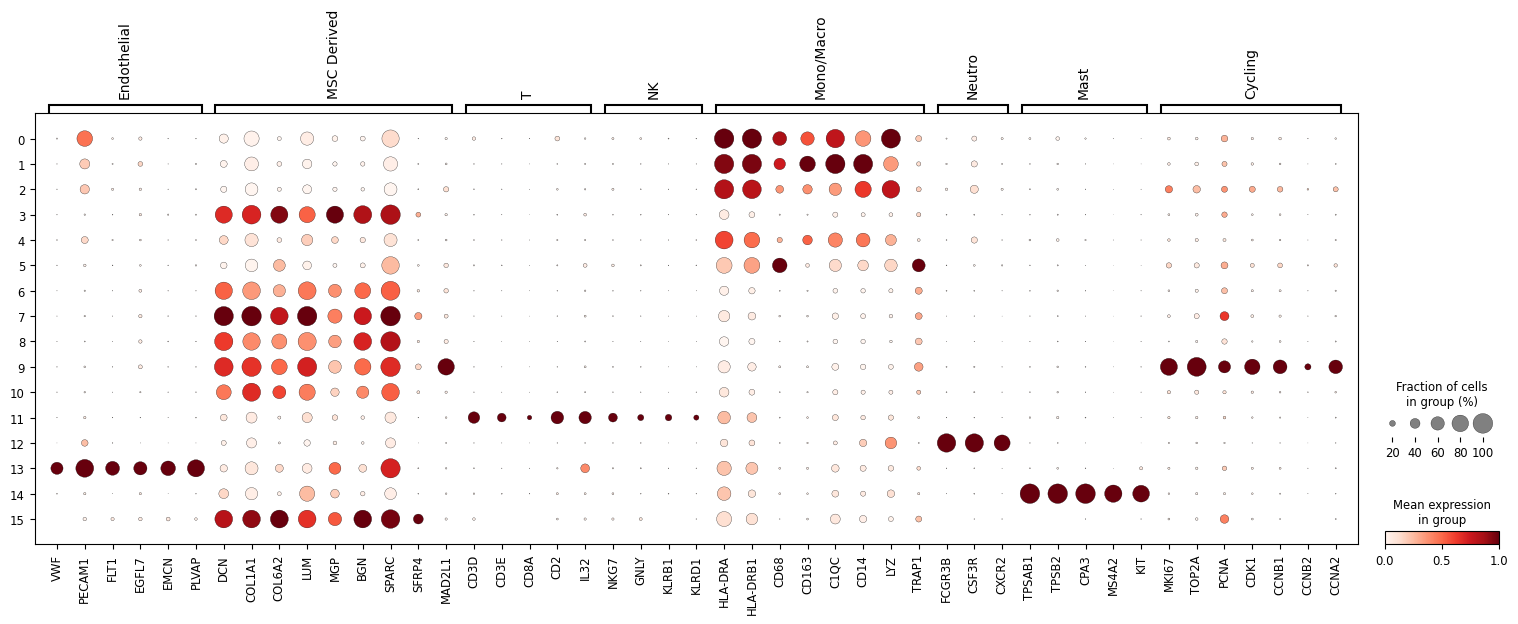

In [8]:
marker_genes = {
    'Endothelial': ['VWF', 'PECAM1', 'FLT1', 'EGFL7', 'EMCN', 'PLVAP'],
    'MSC Derived': ['DCN', 'COL1A1', 'COL6A2', 'LUM', 'MGP', 'BGN', 'SPARC', 'SFRP4', 'MAD2L1'],
    'T': ['CD3D', 'CD3E', 'CD8A', 'CD2', 'IL32'],
    'NK': ['NKG7', 'GNLY', 'KLRB1', 'KLRD1'],
    'Mono/Macro': ['HLA-DRA', 'HLA-DRB1', 'CD68', 'CD163', 'C1QC', 'CD14', 'LYZ', 'TRAP1'],
    'Neutro': ['FCGR3B', 'CSF3R', 'CXCR2'],
    'Mast': ['TPSAB1', 'TPSB2', 'CPA3', 'MS4A2', 'KIT'],
    'Cycling': ['MKI67', 'TOP2A', 'PCNA', 'CDK1', 'CCNB1', 'CCNB2', 'CCNA2'],
}
sc.pl.dotplot(adata, marker_genes, groupby='leiden_lvl1_0.5', standard_scale='var')

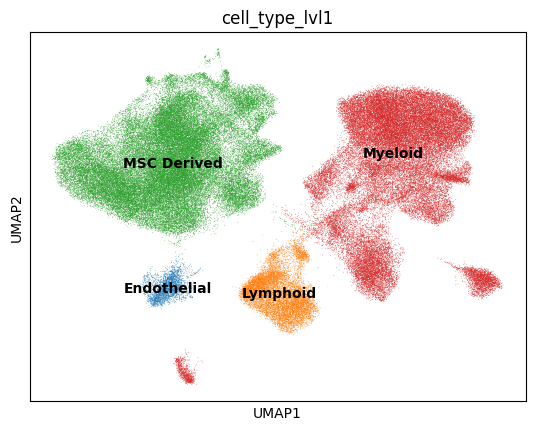

In [9]:
adata.obs['cell_type_lvl1'] = adata.obs['leiden_lvl1_0.5'].map(
    {
        '0': 'Myeloid',
        '1': 'Myeloid',
        '2': 'Myeloid',
        '3': 'MSC Derived',  # benign according to copykat
        '4': 'Myeloid',
        '5': 'Myeloid',  # osteoclast
        '6': 'MSC Derived',
        '7': 'MSC Derived',
        '8': 'MSC Derived',
        '9': 'MSC Derived',
        '10': 'MSC Derived',
        '11': 'Lymphoid',
        '12': 'Myeloid',  # neutrophil
        '13': 'Endothelial',
        '14': 'Myeloid',  # mast
        '15': 'MSC Derived',  # 15 found predominantly in one sample
    }
)
sc.pl.umap(adata, color=['cell_type_lvl1'], legend_loc='on data')

In [10]:
# save
adata.write('%s/small_annotated_lvl1.h5ad' % out_dir)